In [1]:
import warnings
warnings.filterwarnings('ignore')
import os

from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

In [5]:
#Functions for printing R^2 and RMSE metrics for both train and test data

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_regression_model(model, Xtr, Xte, ytr, yte, label, results_list):
    model.fit(Xtr, ytr)

    y_train_pred = model.predict(Xtr)
    y_test_pred = model.predict(Xte)

    train_r2 = r2_score(ytr, y_train_pred)
    test_r2 = r2_score(yte, y_test_pred)
    train_rmse = rmse(ytr, y_train_pred)
    test_rmse = rmse(yte, y_test_pred)

    print(f'=== {label} ===')
    print(f'Train R² : {train_r2:.6f}')
    print(f'Test R²  : {test_r2:.6f}')
    print(f'Train RMSE: {train_rmse:.6f}')
    print(f'Test RMSE : {test_rmse:.6f}')
    print(f'R² gap    : {train_r2 - test_r2:.6f}')
    print(f'RMSE gap  : {test_rmse - train_rmse:.6f}')

    results_list.append({
        'Model': label,
        'R2 Train': train_r2,
        'R2 Test': test_r2,
        'RMSE Train': train_rmse,
        'RMSE': test_rmse,
        'Source': 'Default' if '(Tuned)' not in label else 'Tuned'
    })

    return model, y_train_pred, y_test_pred


# Team 03 – Regression Modeling

### 1. Load Data (5 pts)

Load the four CSV files from Notebook 03.  
* Confirm column alignment with an assert statement.  
* Shapes of X train and X test
  X_train (768 x 8)
  X_test  (154 x 8)
* Target range (regression)
  6.01 to 43.10
* Using scaled data for models:
  Linear, Ridge, and Lasso
* Using unscaled data for models:
  Decision tree, Random Forest, Gradient Boosting

In [52]:
#Data load option A (Matthan)
df = pd.read_csv('../data/raw/ee.csv')

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

X_train = X_train.drop('cooling_load', axis=1)
X_test = X_test.drop('cooling_load', axis=1)

assert list(X_train.columns) == list(X_test.columns), 'Train/test columns are not aligned.'

print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/ee.csv'

In [9]:
#Data load option B (Brandon)
os.chdir("C:/Users/Smith/anaconda3/Projects/DS_Capstone")

df = pd.read_csv('data/processed/df_dropped.csv')

X_train = pd.read_csv('data/modeling/X_train.csv')
X_test = pd.read_csv('data/modeling/X_test.csv')
y_train = pd.read_csv('data/modeling/y_train.csv')
y_test = pd.read_csv('data/modeling/y_test.csv')

assert list(X_train.columns) == list(X_test.columns), 'Train/test columns are not aligned.'

print(f'X_train Loaded: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train Loaded: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test Loaded: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test Loaded: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

X_train Loaded: 614 rows x 17 columns
y_train Loaded: 614 rows x 1 columns
X_test Loaded: 154 rows x 17 columns
y_test Loaded: 154 rows x 1 columns


In [12]:
X_train.head()

,relative_compactness,surface_area,wall_area,roof_area,overall_height,glazing_area,surface_wall_ratio,height_surface_interaction,high_glazing,orientation_3,orientation_4,orientation_5,glazing_area_dist_1,glazing_area_dist_2,glazing_area_dist_3,glazing_area_dist_4,glazing_area_dist_5
0,0.82,612.5,318.5,147.0,7.0,0.10,1.923077,4287.50,0,False,False,False,True,False,False,False,False
1,0.64,784.0,343.0,220.5,3.5,0.40,2.285714,2744.00,1,False,True,False,False,True,False,False,False
2,0.86,588.0,294.0,147.0,7.0,0.25,2.000000,4116.00,0,False,True,False,False,True,False,False,False
3,0.90,563.5,318.5,122.5,7.0,0.25,1.769231,3944.50,0,False,True,False,True,False,False,False,False
4,0.66,759.5,318.5,220.5,3.5,0.10,2.384615,2658.25,0,False,False,True,False,False,False,True,False


In [14]:
y_train.head()

,heating_load
0,23.53
1,18.90
2,29.27
3,32.84
4,11.43


In [16]:
y_test = y_test.squeeze()
y_train = y_train.squeeze()

In [18]:
y_test.head()

0    16.47
1    13.17
2    32.82
3    41.32
4    16.69
Name: heating_load, dtype: float64

In [20]:
print('\nTarget range')
print(f'y_train min={y_train.min():.2f}, max={y_train.max():.2f}')
print(f'y_test min={y_test.min():.2f}, max={y_test.max():.2f}')


Target range
y_train min=6.01, max=43.10
y_test min=6.37, max=42.96


In [22]:
# Create scaled copies of the predictor matrices for linear models only
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Scaled X_train means:')
print(X_train_scaled.mean().round(4).head())
print('\nScaled X_train std devs:')
print(X_train_scaled.std().round(4).head())


Scaled X_train means:
relative_compactness   -0.0
surface_area           -0.0
wall_area               0.0
roof_area              -0.0
overall_height         -0.0
dtype: float64

Scaled X_train std devs:
relative_compactness    1.0008
surface_area            1.0008
wall_area               1.0008
roof_area               1.0008
overall_height          1.0008
dtype: float64


### 2. All Models - Default Parameters

* Fit every required model with default hyperparameters.
* Initialise one empty list (results = [])
at the top of this section and append a result dictionary after every model.
* For each model: train, predict, and print metrics.
* Compare training and test metrics side by side to check for overfitting

In [25]:
results = []

#### Model 1: Linear Regression, unscaled data

In [28]:
lr_unscaled = LinearRegression()
lr_unscaled, y_train_pred_lr_unscaled, y_test_pred_lr_unscaled = evaluate_regression_model(
    lr_unscaled, X_train, X_test, y_train, y_test, 'Linear Regression (Unscaled)', results
)

=== Linear Regression (Unscaled) ===
Train R² : 0.947902
Test R²  : 0.948760
Train RMSE: 2.293011
Test RMSE : 2.311020
R² gap    : -0.000858
RMSE gap  : 0.018010


#### Model 2: Linear Regression, scaled data

In [31]:
lr_scaled = LinearRegression()
lr_scaled, y_train_pred_lr_scaled, y_test_pred_lr_scaled = evaluate_regression_model(
    lr_scaled, X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression (Scaled)', results
)

=== Linear Regression (Scaled) ===
Train R² : 0.947902
Test R²  : 0.948760
Train RMSE: 2.293011
Test RMSE : 2.311020
R² gap    : -0.000858
RMSE gap  : 0.018010


#### Model 3: Ridge Regression, scaled

In [34]:
ridge_default = Ridge(alpha=1.0, random_state=4950)
ridge_default, y_train_pred_ridge, y_test_pred_ridge = evaluate_regression_model(
    ridge_default, X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge Regression', results
)

=== Ridge Regression ===
Train R² : 0.927795
Test R²  : 0.923850
Train RMSE: 2.699482
Test RMSE : 2.817318
R² gap    : 0.003946
RMSE gap  : 0.117837


### Model 4: Lasso Regression

In [37]:
lasso_default = Lasso(alpha=0.01, random_state=4950, max_iter=10000)
lasso_default, y_train_pred_lasso, y_test_pred_lasso = evaluate_regression_model(
    lasso_default, X_train_scaled, X_test_scaled, y_train, y_test, 'Lasso Regression', results
)

lasso_coef = pd.Series(lasso_default.coef_, index=X_train.columns)
print('\nLasso coefficients:')
print(lasso_coef.sort_values(key=np.abs, ascending=False))
print(f'\nNumber of zeroed coefficients: {(lasso_coef == 0).sum()}')


=== Lasso Regression ===
Train R² : 0.926904
Test R²  : 0.922902
Train RMSE: 2.716088
Test RMSE : 2.834787
R² gap    : 0.004002
RMSE gap  : 0.118699

Lasso coefficients:
height_surface_interaction    6.211588
roof_area                    -3.248560
glazing_area                  2.396103
glazing_area_dist_2           1.485767
glazing_area_dist_3           1.463444
glazing_area_dist_1           1.430305
glazing_area_dist_5           1.416237
glazing_area_dist_4           1.279942
wall_area                     0.691795
surface_wall_ratio            0.354127
orientation_5                -0.059678
high_glazing                 -0.053463
orientation_3                -0.023873
orientation_4                -0.000000
surface_area                 -0.000000
overall_height               -0.000000
relative_compactness          0.000000
dtype: float64

Number of zeroed coefficients: 4


#### Model 5: Decision Tree

In [40]:
dt_default = DecisionTreeRegressor(max_depth=10, random_state=4950)
dt_default, y_train_pred_dt, y_test_pred_dt = evaluate_regression_model(
    dt_default, X_train, X_test, y_train, y_test, 'Decision Tree', results
)

=== Decision Tree ===
Train R² : 0.999714
Test R²  : 0.995826
Train RMSE: 0.170031
Test RMSE : 0.659559
R² gap    : 0.003887
RMSE gap  : 0.489528


#### Model 6: Random Forest

In [43]:
rf_default = RandomForestRegressor(n_estimators=100, random_state=4950)
rf_default, y_train_pred_rf, y_test_pred_rf = evaluate_regression_model(
    rf_default, X_train, X_test, y_train, y_test, 'Random Forest', results
)

=== Random Forest ===
Train R² : 0.999635
Test R²  : 0.997429
Train RMSE: 0.191835
Test RMSE : 0.517695
R² gap    : 0.002207
RMSE gap  : 0.325860


#### Model 7: Gradient Boosting

In [46]:
gb_default = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=4950)
gb_default, y_train_pred_gb, y_test_pred_gb = evaluate_regression_model(
    gb_default, X_train, X_test, y_train, y_test, 'Gradient Boosting', results
)

=== Gradient Boosting ===
Train R² : 0.998508
Test R²  : 0.997969
Train RMSE: 0.388073
Test RMSE : 0.460061
R² gap    : 0.000538
RMSE gap  : 0.071987


#### Model comparison



In [49]:
results_df = pd.DataFrame(results)
results_df = results_df[results_df['Source'] == 'Default'].sort_values('R2 Test', ascending=False)
results_df


,Model,R2 Train,R2 Test,RMSE Train,RMSE,Source
6,Gradient Boosting,0.998508,0.997969,0.388073,0.460061,Default
5,Random Forest,0.999635,0.997429,0.191835,0.517695,Default
4,Decision Tree,0.999714,0.995826,0.170031,0.659559,Default
1,Linear Regression (Scaled),0.947902,0.948760,2.293011,2.311020,Default
0,Linear Regression (Unscaled),0.947902,0.948760,2.293011,2.311020,Default
2,Ridge Regression,0.927795,0.923850,2.699482,2.817318,Default
3,Lasso Regression,0.926904,0.922902,2.716088,2.834787,Default


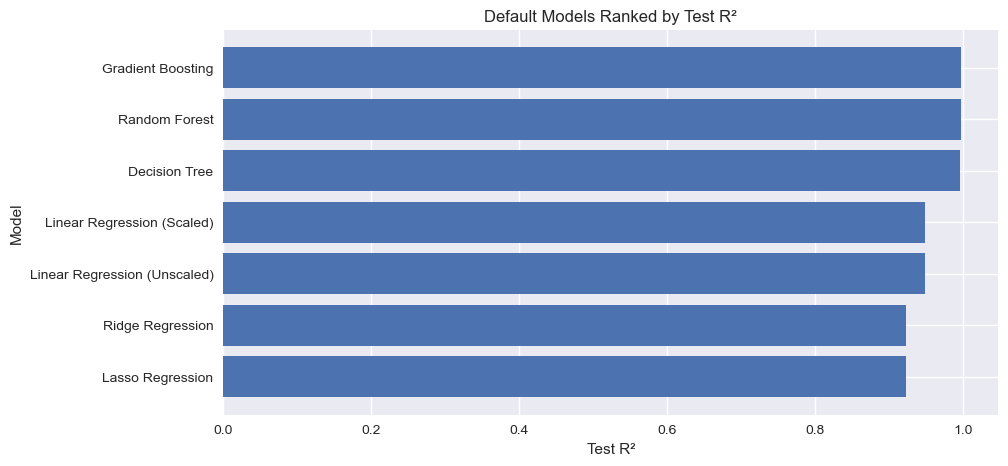

In [51]:
plt.figure(figsize=(10, 5))
plt.barh(results_df['Model'], results_df['R2 Test'])
plt.xlabel('Test R²')
plt.ylabel('Model')
plt.title('Default Models Ranked by Test R²')
plt.gca().invert_yaxis()
plt.show()


### Best Performer?
Random forest has the best R squared, albeit only by the slightest amounts. As for overfitting, there's very slight differences between Train and Test, so I'd say no models were overfit. Continuing with tuning ridge, random forest, and gradient boosting.

### 3. Cross-Validation (20 pts)
Run 5-fold cross-validation on all models using the CV object defined above. Use scoring="roc auc"
for classification and scoring="r2" for regression.
Deliver:
* CV mean and std for every model, printed after each cross val score call
* A summary DataFrame with columns: Model, CV Mean, CV Std, and all 5 fold scores
* A horizontal bar chart with error bars (xerr = CV Std), sorted by CV Mean.
* Write a markdown cell addressing: Do CV means agree with the test-set results from Section 2?
Flag any model with CV Std > 0.03 as potentially unstable.

In [55]:
cv = KFold(n_splits=5, shuffle=True, random_state=4950)
print(cv)


KFold(n_splits=5, random_state=4950, shuffle=True)


In [57]:
cv_models = {
    'Linear Regression, Unscaled': LinearRegression(),
    'Linear Regression, Scaled': make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge Regression': make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=4950)),
    'Lasso Regression': make_pipeline(StandardScaler(), Lasso(alpha=0.01, random_state=4950, max_iter=10000)),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=4950),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=4950),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=4950)
}

cv_rows = []

for model_name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    print(f'{model_name}')
    print(f'  CV mean = {scores.mean():.6f}')
    print(f'  CV std  = {scores.std():.6f}')
    print(f'  folds   = {np.round(scores, 6)}\n')

    row = {
        'Model': model_name,
        'CV Mean': scores.mean(),
        'CV Std': scores.std()
    }
    for i, score in enumerate(scores, start=1):
        row[f'Fold {i}'] = score
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values('CV Mean', ascending=False)
cv_results_df


Linear Regression, Unscaled
  CV mean = 0.942816
  CV std  = 0.005924
  folds   = [0.951686 0.946005 0.933823 0.942013 0.940552]

Linear Regression, Scaled
  CV mean = 0.942816
  CV std  = 0.005924
  folds   = [0.951686 0.946005 0.933823 0.942013 0.940552]

Ridge Regression
  CV mean = 0.921908
  CV std  = 0.010760
  folds   = [0.930492 0.928728 0.923957 0.925475 0.90089 ]

Lasso Regression
  CV mean = 0.921176
  CV std  = 0.011601
  folds   = [0.930122 0.929093 0.924318 0.923829 0.89852 ]

Decision Tree
  CV mean = 0.996704
  CV std  = 0.000208
  folds   = [0.996757 0.997017 0.99666  0.996719 0.996367]

Random Forest
  CV mean = 0.997027
  CV std  = 0.000703
  folds   = [0.996165 0.997524 0.997714 0.997557 0.996175]

Gradient Boosting
  CV mean = 0.997891
  CV std  = 0.000360
  folds   = [0.997435 0.99844  0.998142 0.997626 0.99781 ]



,Model,CV Mean,CV Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
6,Gradient Boosting,0.997891,0.000360,0.997435,0.998440,0.998142,0.997626,0.997810
5,Random Forest,0.997027,0.000703,0.996165,0.997524,0.997714,0.997557,0.996175
4,Decision Tree,0.996704,0.000208,0.996757,0.997017,0.996660,0.996719,0.996367
0,"Linear Regression, Unscaled",0.942816,0.005924,0.951686,0.946005,0.933823,0.942013,0.940552
1,"Linear Regression, Scaled",0.942816,0.005924,0.951686,0.946005,0.933823,0.942013,0.940552
2,Ridge Regression,0.921908,0.010760,0.930492,0.928728,0.923957,0.925475,0.900890
3,Lasso Regression,0.921176,0.011601,0.930122,0.929093,0.924318,0.923829,0.898520


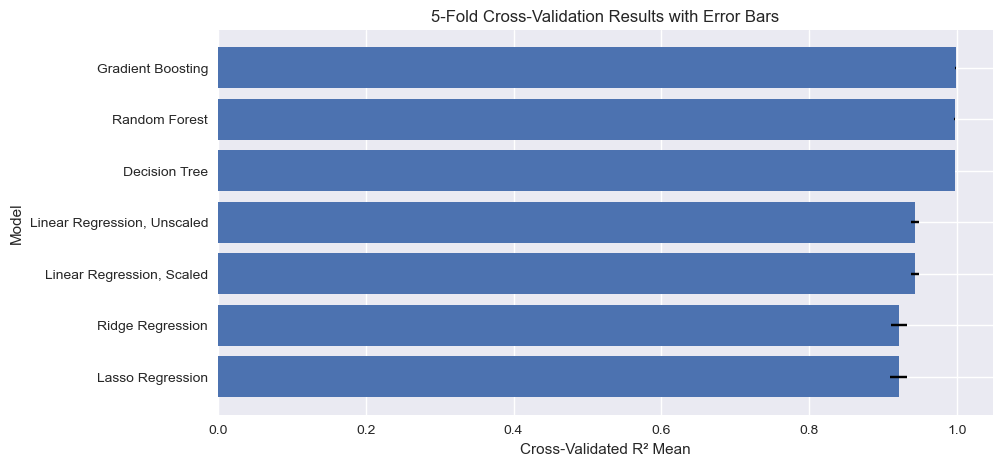

In [59]:
plt.figure(figsize=(10, 5))
plt.barh(cv_results_df['Model'], cv_results_df['CV Mean'], xerr=cv_results_df['CV Std'])
plt.xlabel('Cross-Validated R² Mean')
plt.ylabel('Model')
plt.title('5-Fold Cross-Validation Results with Error Bars')
plt.gca().invert_yaxis()
plt.show()


In [61]:
cv_results_df['Potentially Unstable'] = cv_results_df['CV Std'] > 0.03
cv_results_df[['Model', 'CV Mean', 'CV Std', 'Potentially Unstable']]


,Model,CV Mean,CV Std,Potentially Unstable
6,Gradient Boosting,0.997891,0.000360,False
5,Random Forest,0.997027,0.000703,False
4,Decision Tree,0.996704,0.000208,False
0,"Linear Regression, Unscaled",0.942816,0.005924,False
1,"Linear Regression, Scaled",0.942816,0.005924,False
2,Ridge Regression,0.921908,0.010760,False
3,Lasso Regression,0.921176,0.011601,False


No potentially unstable models, means agree when compared to test data.

### 4. Hyperparameter Tuning — GridSearchCV (30 pts)
Tune at least three models using GridSearchCV with the same CV object from Section 3. Append
every tuned result to the same results list with a label such as “Random Forest (Tuned)”.
* Tuning Ridge Regression, Random forest, and Gradient Boosting.


### Tuning 1: Ridge Regression
alpha: [0.001, 0.01, 0.1, 1, 10, 100, 1000]

In [66]:
ridge_param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    estimator=make_pipeline(StandardScaler(), Ridge(random_state=4950)),
    param_grid=ridge_param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=1,
    return_train_score=True
)

ridge_grid.fit(X_train, y_train)

ridge_cv_df = pd.DataFrame(ridge_grid.cv_results_)[[
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'param_ridge__alpha'
]].sort_values('rank_test_score')

print('Best parameters:', ridge_grid.best_params_)
print(f'Best CV mean: {ridge_grid.best_score_:.6f}')
print('\nTop 5 CV combinations:')
print(ridge_cv_df.head(5).to_string(index=False))


Best parameters: {'ridge__alpha': 0.001}
Best CV mean: 0.942839

Top 5 CV combinations:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_ridge__alpha
               1         0.942839        0.005706          0.948402               0.001
               2         0.941064        0.005949          0.946455               0.010
               3         0.928422        0.009427          0.934369               0.100
               4         0.921908        0.010760          0.928108               1.000
               5         0.920093        0.011184          0.925999              10.000


In [68]:
ridge_best = ridge_grid.best_estimator_
ridge_cv_scores = cross_val_score(ridge_best, X_train, y_train, cv=cv, scoring='r2')

print('Best estimator CV scores:', np.round(ridge_cv_scores, 6))
print(f'CV mean = {ridge_cv_scores.mean():.6f}')
print(f'CV std  = {ridge_cv_scores.std():.6f}\n')

ridge_best, _, _ = evaluate_regression_model(
    ridge_best, X_train, X_test, y_train, y_test, 'Ridge Regression (Tuned)', results
)


Best estimator CV scores: [0.951576 0.946009 0.934757 0.942306 0.939548]
CV mean = 0.942839
CV std  = 0.005706

=== Ridge Regression (Tuned) ===
Train R² : 0.947878
Test R²  : 0.948542
Train RMSE: 2.293542
Test RMSE : 2.315944
R² gap    : -0.000663
RMSE gap  : 0.022403


### Tuning 2: Random Forest
max depth, max features

In [71]:
rf_param_grid = {
    'max_depth': [5, 10, 15, None],
    'max_features': [1.0, 'sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=100, random_state=4950),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

rf_cv_df = pd.DataFrame(rf_grid.cv_results_)[[
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_max_depth', 'param_max_features'
]].sort_values('rank_test_score')

print('Best params:', rf_grid.best_params_)
print(f'Best CV mean: {rf_grid.best_score_:.6f}')
print('\nTop 5 CV combinations:')
print(rf_cv_df.head(5).to_string(index=False))


Best params: {'max_depth': 15, 'max_features': 1.0}
Best CV mean: 0.997027

Top 5 CV combinations:
 rank_test_score  mean_test_score  std_test_score  mean_train_score param_max_depth param_max_features
               1         0.997027        0.000703          0.999595              15                1.0
               1         0.997027        0.000703          0.999595            None                1.0
               3         0.997023        0.000713          0.999532              10                1.0
               4         0.991989        0.003081          0.998825              15               sqrt
               4         0.991989        0.003081          0.998825              15               log2


In [72]:
rf_best = rf_grid.best_estimator_
rf_cv_scores = cross_val_score(rf_best, X_train, y_train, cv=cv, scoring='r2')

print('Best estimator CV scores:', np.round(rf_cv_scores, 6))
print(f'CV mean = {rf_cv_scores.mean():.6f}')
print(f'CV std  = {rf_cv_scores.std():.6f}\n')

rf_best, _, _ = evaluate_regression_model(
    rf_best, X_train, X_test, y_train, y_test, 'Random Forest (Tuned)', results
)


Best estimator CV scores: [0.996165 0.997524 0.997714 0.997557 0.996175]
CV mean = 0.997027
CV std  = 0.000703

=== Random Forest (Tuned) ===
Train R² : 0.999635
Test R²  : 0.997429
Train RMSE: 0.191835
Test RMSE : 0.517695
R² gap    : 0.002207
RMSE gap  : 0.325860


### Tuning 3: Gradient Boosting
n estimators, learning rate, max depth

In [74]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=4950),
    param_grid=gb_param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=1,
    return_train_score=True
)

gb_grid.fit(X_train, y_train)

gb_cv_df = pd.DataFrame(gb_grid.cv_results_)[[
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_n_estimators', 'param_learning_rate', 'param_max_depth'
]].sort_values('rank_test_score')

print('Best parameters:', gb_grid.best_params_)
print(f'Best CV mean: {gb_grid.best_score_:.6f}')
print('\nTop 5 CV combinations:')
print(gb_cv_df.head(5).to_string(index=False))


Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best CV mean: 0.998272

Top 5 CV combinations:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_n_estimators  param_learning_rate  param_max_depth
               1         0.998272        0.000270          0.999328                 200                 0.20                3
               2         0.998256        0.000255          0.999565                 200                 0.10                4
               3         0.998159        0.000186          0.999830                 200                 0.20                4
               4         0.998154        0.000357          0.999105                 200                 0.05                4
               5         0.998147        0.000356          0.998962                 200                 0.10                3


In [78]:
gb_best = gb_grid.best_estimator_
gb_cv_scores = cross_val_score(gb_best, X_train, y_train, cv=cv, scoring='r2')

print('Best estimator CV scores:', np.round(gb_cv_scores, 6))
print(f'CV mean = {gb_cv_scores.mean():.6f}')
print(f'CV std  = {gb_cv_scores.std():.6f}\n')

gb_best, y_train_pred_best, y_test_pred_best = evaluate_regression_model(
    gb_best, X_train, X_test, y_train, y_test, 'Gradient Boosting (Tuned)', results
)


Best estimator CV scores: [0.997943 0.998695 0.998145 0.998112 0.998464]
CV mean = 0.998272
CV std  = 0.000270

=== Gradient Boosting (Tuned) ===
Train R² : 0.999190
Test R²  : 0.998413
Train RMSE: 0.285988
Test RMSE : 0.406689
R² gap    : 0.000776
RMSE gap  : 0.120701


In [79]:
tuning_compare_df = pd.DataFrame(results)
tuning_compare_df[tuning_compare_df['Model'].isin([
    'Ridge Regression', 'Ridge Regression (Tuned)',
    'Random Forest', 'Random Forest (Tuned)',
    'Gradient Boosting', 'Gradient Boosting (Tuned)'
])].sort_values('R2 Test', ascending=False)


,Model,R2 Train,R2 Test,RMSE Train,RMSE,Source
9,Gradient Boosting (Tuned),0.999190,0.998413,0.285988,0.406689,Tuned
6,Gradient Boosting,0.998508,0.997969,0.388073,0.460061,Default
5,Random Forest,0.999635,0.997429,0.191835,0.517695,Default
8,Random Forest (Tuned),0.999635,0.997429,0.191835,0.517695,Tuned
7,Ridge Regression (Tuned),0.947878,0.948542,2.293542,2.315944,Tuned
2,Ridge Regression,0.927795,0.923850,2.699482,2.817318,Default


### 5. Final Model Comparison

In [83]:
results_df_final = pd.DataFrame(results).sort_values('R2 Test', ascending=False)
results_df_final


,Model,R2 Train,R2 Test,RMSE Train,RMSE,Source
9,Gradient Boosting (Tuned),0.999190,0.998413,0.285988,0.406689,Tuned
6,Gradient Boosting,0.998508,0.997969,0.388073,0.460061,Default
5,Random Forest,0.999635,0.997429,0.191835,0.517695,Default
8,Random Forest (Tuned),0.999635,0.997429,0.191835,0.517695,Tuned
4,Decision Tree,0.999714,0.995826,0.170031,0.659559,Default
1,Linear Regression (Scaled),0.947902,0.948760,2.293011,2.311020,Default
0,Linear Regression (Unscaled),0.947902,0.948760,2.293011,2.311020,Default
7,Ridge Regression (Tuned),0.947878,0.948542,2.293542,2.315944,Tuned
2,Ridge Regression,0.927795,0.923850,2.699482,2.817318,Default
3,Lasso Regression,0.926904,0.922902,2.716088,2.834787,Default


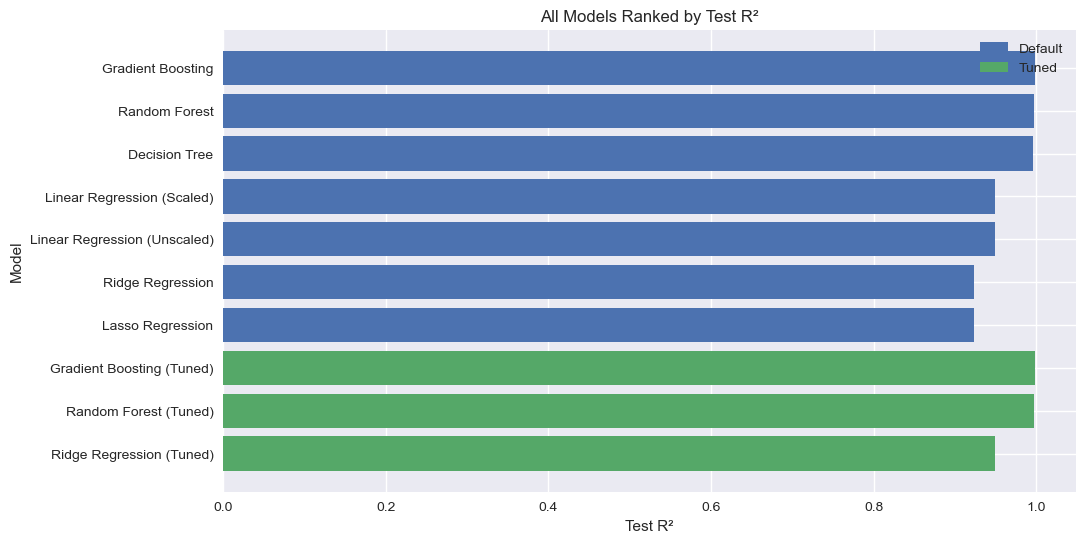

In [85]:
plt.figure(figsize=(11, 6))

default_mask = results_df_final['Source'] == 'Default'
tuned_mask = results_df_final['Source'] == 'Tuned'

plt.barh(results_df_final.loc[default_mask, 'Model'], results_df_final.loc[default_mask, 'R2 Test'], label='Default')
plt.barh(results_df_final.loc[tuned_mask, 'Model'], results_df_final.loc[tuned_mask, 'R2 Test'], label='Tuned')

plt.xlabel('Test R²')
plt.ylabel('Model')
plt.title('All Models Ranked by Test R²')
plt.legend()
plt.gca().invert_yaxis()
plt.show()


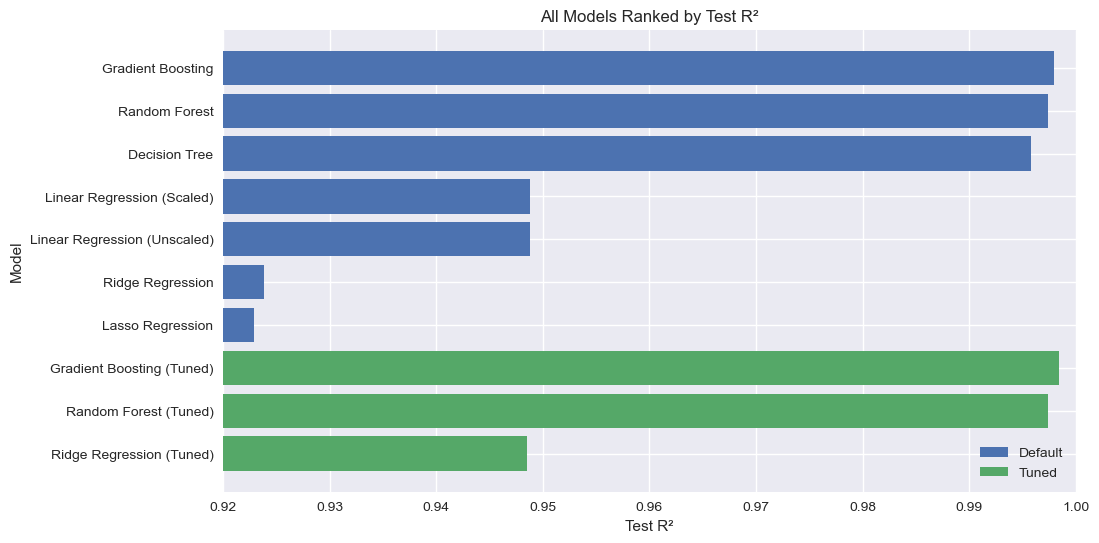

In [93]:
#More distinguishable graph
plt.figure(figsize=(11, 6))

default_mask = results_df_final['Source'] == 'Default'
tuned_mask = results_df_final['Source'] == 'Tuned'

plt.barh(results_df_final.loc[default_mask, 'Model'], results_df_final.loc[default_mask, 'R2 Test'], label='Default')
plt.barh(results_df_final.loc[tuned_mask, 'Model'], results_df_final.loc[tuned_mask, 'R2 Test'], label='Tuned')

plt.xlabel('Test R²')
plt.ylabel('Model')
plt.title('All Models Ranked by Test R²')
plt.xlim(0.92, 1)
plt.legend()
plt.gca().invert_yaxis()
plt.show()


In [95]:
# Select the best model based on R^2
model_lookup = {
    'Linear Regression (Unscaled)': lr_unscaled,
    'Linear Regression (Scaled)': lr_scaled,
    'Ridge Regression': ridge_default,
    'Lasso Regression': lasso_default,
    'Decision Tree': dt_default,
    'Random Forest': rf_default,
    'Gradient Boosting': gb_default,
    'Ridge Regression (Tuned)': ridge_best,
    'Random Forest (Tuned)': rf_best,
    'Gradient Boosting (Tuned)': gb_best
}

best_model_name = results_df_final.iloc[0]['Model']
best_model = model_lookup[best_model_name]

print('Best model:  ', best_model_name)
print(results_df_final.iloc[0][['R2 Test', 'RMSE', 'R2 Train', 'RMSE Train']])


Best model:   Gradient Boosting (Tuned)
R2 Test       0.998413
RMSE          0.406689
R2 Train       0.99919
RMSE Train    0.285988
Name: 9, dtype: object


In [97]:
#Calculate predictions for best model

if best_model_name in ['Linear Regression (Scaled)', 'Ridge Regression', 'Lasso Regression']:
    Xtr_plot = X_train_scaled
    Xte_plot = X_test_scaled
else:
    Xtr_plot = X_train
    Xte_plot = X_test

best_model.fit(Xtr_plot, y_train)
best_train_pred = best_model.predict(Xtr_plot)
best_test_pred = best_model.predict(Xte_plot)
best_residuals = y_test - best_test_pred


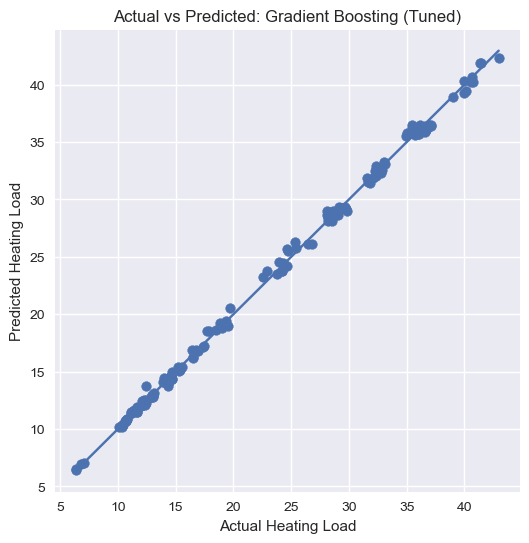

In [99]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_test_pred)
plt.xlabel('Actual Heating Load')
plt.ylabel('Predicted Heating Load')
plt.title(f'Actual vs Predicted: {best_model_name}')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()


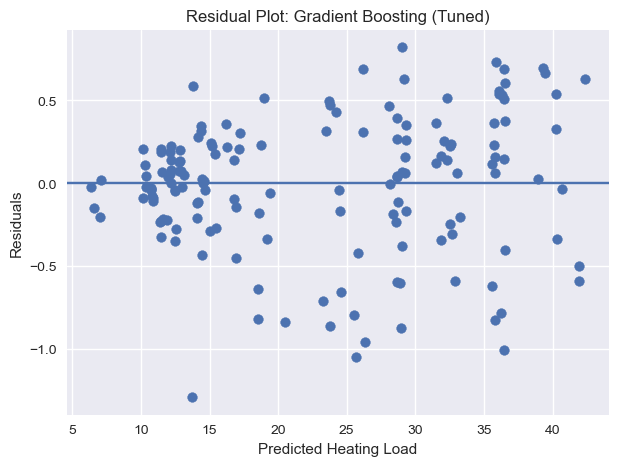

In [101]:
plt.figure(figsize=(7, 5))
plt.scatter(best_test_pred, best_residuals)
plt.axhline(0)
plt.xlabel('Predicted Heating Load')
plt.ylabel('Residuals')
plt.title(f'Residual Plot: {best_model_name}')
plt.show()


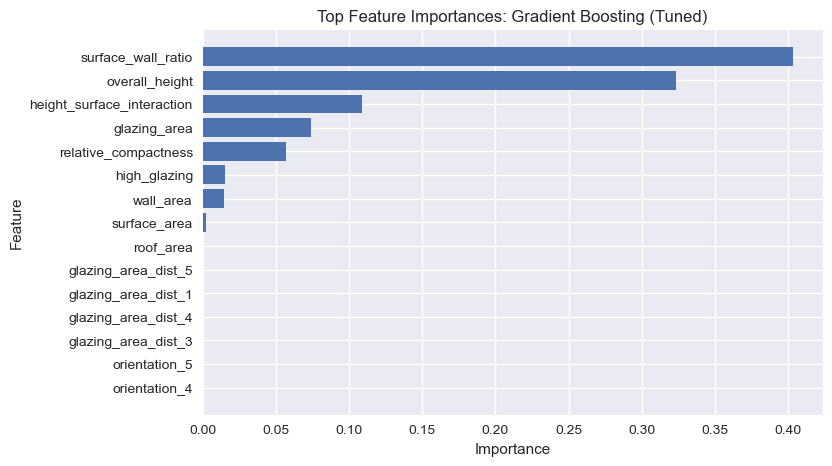

surface_wall_ratio            0.403442
overall_height                0.323538
height_surface_interaction    0.108732
glazing_area                  0.073899
relative_compactness          0.056875
high_glazing                  0.014975
wall_area                     0.014915
surface_area                  0.002457
roof_area                     0.000344
glazing_area_dist_5           0.000187
glazing_area_dist_1           0.000123
glazing_area_dist_4           0.000116
glazing_area_dist_3           0.000113
orientation_5                 0.000094
orientation_4                 0.000091
dtype: float64


In [103]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)
    plt.figure(figsize=(8, 5))
    plt.barh(importances.index, importances.values)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Top Feature Importances: {best_model_name}')
    plt.show()
    print(importances.sort_values(ascending=False))
else:
    coef = pd.Series(best_model.coef_, index=X_train.columns)
    importances = coef.abs().sort_values(ascending=True).tail(15)
    plt.figure(figsize=(8, 5))
    plt.barh(importances.index, importances.values)
    plt.xlabel('Absolute Coefficient')
    plt.ylabel('Feature')
    plt.title(f'Top Absolute Coefficients: {best_model_name}')
    plt.show()
    print(coef.sort_values(key=np.abs, ascending=False))


### Final model selection

In [106]:
cv_lookup = {}

for row in cv_rows:
    cv_lookup[row['Model']] = (row['CV Mean'], row['CV Std'])

# Add tuned-model CV summaries
cv_lookup['Ridge Regression (Tuned)'] = (ridge_cv_scores.mean(), ridge_cv_scores.std())
cv_lookup['Random Forest (Tuned)'] = (rf_cv_scores.mean(), rf_cv_scores.std())
cv_lookup['Gradient Boosting (Tuned)'] = (gb_cv_scores.mean(), gb_cv_scores.std())

best_default_row = results_df_final[results_df_final['Source'] == 'Default'].sort_values('R2 Test', ascending=False).iloc[0]
winning_row = results_df_final.iloc[0]

winning_cv_mean, winning_cv_std = cv_lookup[best_model_name]
improvement_over_best_default = winning_row['R2 Test'] - best_default_row['R2 Test']

print('Best model summary')
print(f"Model: {best_model_name}")
print(f"Test R²: {winning_row['R2 Test']:.6f}")
print(f"Test RMSE: {winning_row['RMSE']:.6f}")
print(f"CV mean ± std: {winning_cv_mean:.6f} ± {winning_cv_std:.6f}")
print(f"Improvement over best default model: {improvement_over_best_default:.6f}")
print(f"Best default model: {best_default_row['Model']}")


Best model summary
Model: Gradient Boosting (Tuned)
Test R²: 0.998413
Test RMSE: 0.406689
CV mean ± std: 0.998272 ± 0.000270
Improvement over best default model: 0.000444
Best default model: Gradient Boosting


Gradient Boosting (Tuned) is selected for best model as it leads the pack in R2 and RMSE.

### 6. Save Best Model (5 pts)
Use pickle to save the winning model to ../models/best model.pkl. Print the model type and
its best parameters. Add a verification cell that loads the file and calls predict() on the first five test rows to confirm the saved model works correctly



In [110]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

best_model_path = models_dir / 'best_model.pkl'

with open(best_model_path, 'wb') as f:
    pickle.dump(best_model, f)

print('Saved model type:', type(best_model).__name__)
print('Saved to:', best_model_path)

if best_model_name == 'Ridge Regression (Tuned)':
    print('Best parameters:', ridge_grid.best_params_)
elif best_model_name == 'Random Forest (Tuned)':
    print('Best parameters:', rf_grid.best_params_)
elif best_model_name == 'Gradient Boosting (Tuned)':
    print('Best parameters:', gb_grid.best_params_)
else:
    print('Best parameters: default model settings used')


Saved model type: GradientBoostingRegressor
Saved to: ..\models\best_model.pkl
Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}


In [118]:
with open(best_model_path, 'rb') as f:
    loaded_model = pickle.load(f)

if best_model_name in ['Linear Regression (Scaled)', 'Ridge Regression', 'Lasso Regression']:
    verification_X = X_test_scaled.head()
else:
    verification_X = X_test.head()

verification_preds = loaded_model.predict(verification_X)

print('Loaded model type:', type(loaded_model).__name__)
print('First five predictions:')
print(np.round(verification_preds, 6))


Loaded model type: GradientBoostingRegressor
First five predictions:
[16.253536 13.12015  32.30576  41.911457 16.783702]


## Key Findings Summary


1. Extremely accurate model, accounting for 99.84% of the data.
3. On average, data is off by only .169734. Closer we can get to zero, the better.